# Notebook 04b: Optical Flow Preprocessing — Lucas-Kanade (Parameter P3)
### SIBI Lip Reading — Dataset Gabungan (Angka + Alphabet + Kata)

Notebook ini menggunakan konfigurasi **P3** dari hasil OFAT sweep:

| Parameter | BaseLK | **P3** |
|-----------|--------|--------|
| maxCorners | 200 | **200** |
| qualityLevel | 0.01 | **0.005** |
| minDistance | 5 | **5** |
| blockSize | 5 | **5** |
| winSize | 15x15 | **15x15** |
| maxLevel | 3 | **3** |

Perubahan dari BaseLK: `qualityLevel` diturunkan dari 0.01 → 0.005 (lebih banyak corner terdeteksi).

**Output:** `flows_lk_p3/*.npy` shape `[29, 96, 96, 3]`

In [1]:
# ── Cell 1: Import ──────────────────────────────────────────────────────────
import os, json, random, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from scipy.interpolate import griddata
warnings.filterwarnings('ignore')

print(f'OpenCV : {cv2.__version__}')
print(f'NumPy  : {np.__version__}')
print('scipy.interpolate tersedia ✓')

OpenCV : 4.13.0
NumPy  : 2.4.3
scipy.interpolate tersedia ✓


In [2]:
# ── Cell 2: Config — Parameter P3 ───────────────────────────────────────────
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
RAW_LIPS     = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
FLOWS_DIR    = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'flows_lk_p3'
STATS_FILE   = FLOWS_DIR / 'norm_stats.json'
RESULTS_DIR  = PROJECT_ROOT / 'results' / 'lk_p3'

FLOWS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(PROJECT_ROOT / 'config.json') as f:
    cfg = json.load(f)

CLASSES  = cfg['data']['classes']
SPLITS   = cfg['data']['splits']

# ── Parameter P3 ────────────────────────────────────────────────────────────
FEAT_PARAMS = dict(
    maxCorners   = 200,
    qualityLevel = 0.005,   # << diubah dari 0.01 → 0.005
    minDistance  = 5,
    blockSize    = 5
)
LK_PARAMS = dict(
    winSize         = (15, 15),
    maxLevel        = 3,
    criteria        = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01),
    minEigThreshold = 1e-4
)
INTERP_METHOD = 'linear'

NUM_CLASSES  = len(CLASSES)
IDX_TO_CLASS = {i: c for i, c in enumerate(CLASSES)}

print(f'Input   : {RAW_LIPS}')
print(f'Output  : {FLOWS_DIR}')
print(f'Classes : {NUM_CLASSES} — {CLASSES}')
print(f'\n── Parameter P3 ──')
print(f'  maxCorners   : {FEAT_PARAMS["maxCorners"]}')
print(f'  qualityLevel : {FEAT_PARAMS["qualityLevel"]}  ← diubah dari 0.01')
print(f'  minDistance  : {FEAT_PARAMS["minDistance"]}')
print(f'  blockSize    : {FEAT_PARAMS["blockSize"]}')
print(f'  maxLevel     : {LK_PARAMS["maxLevel"]}')
print(f'  griddata     : {INTERP_METHOD}')

Input   : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/raw_lips
Output  : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lk_p3
Classes : 18 — ['1', '2', '3', '8', '9', '10', 'a', 'b', 'c', 'd', 'e', 'f', 'buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']

── Parameter P3 ──
  maxCorners   : 200
  qualityLevel : 0.005  ← diubah dari 0.01
  minDistance  : 5
  blockSize    : 5
  maxLevel     : 3
  griddata     : linear


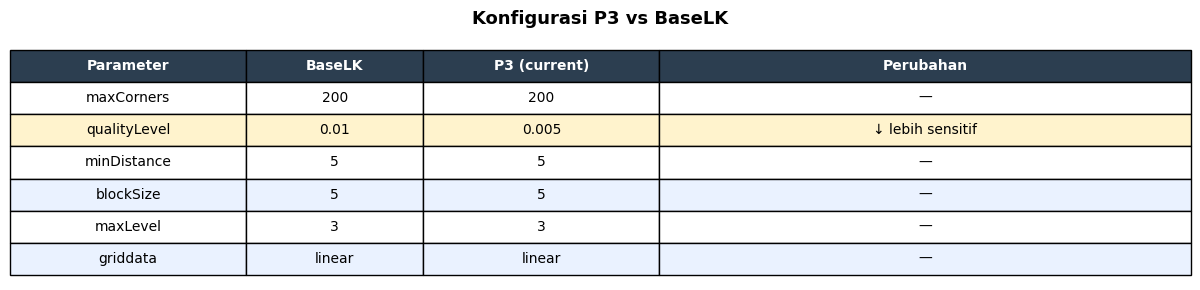

Saved: p3_parameters.png


In [3]:
# ── Cell 3: Tabel perbandingan parameter ────────────────────────────────────
param_data = {
    'Parameter'    : ['maxCorners', 'qualityLevel', 'minDistance', 'blockSize', 'maxLevel', 'griddata'],
    'BaseLK'       : [200, 0.01,  5, 5, 3, 'linear'],
    'P3 (current)' : [200, 0.005, 5, 5, 3, 'linear'],
    'Perubahan'    : ['—', '↓ lebih sensitif', '—', '—', '—', '—'],
}

fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
df_p = pd.DataFrame(param_data)
tbl  = ax.table(cellText=df_p.values, colLabels=df_p.columns,
                cellLoc='center', loc='center', colWidths=[0.2, 0.15, 0.2, 0.45])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.9)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#EAF2FF')
    # highlight baris yang berubah
    if r == 2:  # qualityLevel row
        cell.set_facecolor('#FFF3CD')
ax.set_title('Konfigurasi P3 vs BaseLK', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p3_parameters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_parameters.png')

---
## Fungsi Optical Flow

In [4]:
# ── Cell 4: Fungsi utama ────────────────────────────────────────────────────
def load_gray(npy_path):
    data = np.load(npy_path)
    return np.array([cv2.cvtColor(f, cv2.COLOR_BGR2GRAY) for f in data])


def sparse_to_dense(src_pts, flow_vecs, H, W):
    if len(src_pts) < 4:
        return np.zeros((H, W, 3), dtype=np.float32)
    gy, gx = np.mgrid[0:H, 0:W]
    grid   = np.column_stack([gx.ravel(), gy.ravel()])
    u = griddata(src_pts, flow_vecs[:, 0], grid, method=INTERP_METHOD, fill_value=0.0).reshape(H, W).astype(np.float32)
    v = griddata(src_pts, flow_vecs[:, 1], grid, method=INTERP_METHOD, fill_value=0.0).reshape(H, W).astype(np.float32)
    return np.stack([u, v, np.sqrt(u**2 + v**2)], axis=-1)


def compute_lk_flow(frames):
    T, H, W = frames.shape
    if T < 2: return None
    flows = []
    for t in range(T - 1):
        p0 = cv2.goodFeaturesToTrack(frames[t], mask=None, **FEAT_PARAMS)
        if p0 is None or len(p0) < 4:
            flows.append(np.zeros((H, W, 3), dtype=np.float32)); continue
        p1, status, _ = cv2.calcOpticalFlowPyrLK(frames[t], frames[t+1], p0, None, **LK_PARAMS)
        mask = status.ravel() == 1
        if mask.sum() < 4:
            flows.append(np.zeros((H, W, 3), dtype=np.float32)); continue
        old = p0[mask].reshape(-1, 2)
        new = p1[mask].reshape(-1, 2)
        flows.append(sparse_to_dense(old, new - old, H, W))
    return np.array(flows, dtype=np.float32)


print('fungsi siap ✓')

fungsi siap ✓


---
## Test & Visualisasi

In [5]:
# ── Cell 5: Test di 1 video per kategori ────────────────────────────────────
test_samples = {
    'Angka'   : cfg['data']['classes_angka'][0],
    'Alphabet': cfg['data']['classes_alphabet'][0],
    'Kata'    : cfg['data']['classes_kata'][0],
}

for kat, cls in test_samples.items():
    files = sorted((RAW_LIPS / 'train' / cls).glob('*.npy'))
    if not files: print(f'[SKIP] {kat}/{cls}'); continue
    flows = compute_lk_flow(load_gray(files[0]))
    if flows is not None:
        print(f'{kat:8s} | "{cls}" | flows {flows.shape}')
        for i, ch in enumerate(['u', 'v', 'mag']):
            d = flows[..., i]
            print(f'           {ch}: min={d.min():+.3f}, max={d.max():+.3f}, mean={d.mean():+.4f}')

Angka    | "1" | flows (29, 96, 96, 3)
           u: min=-53.378, max=+98.923, mean=+0.1418
           v: min=-61.751, max=+81.878, mean=+0.1991
           mag: min=+0.000, max=+101.458, mean=+2.4683
Alphabet | "a" | flows (29, 96, 96, 3)
           u: min=-49.752, max=+45.682, mean=+0.0512
           v: min=-56.033, max=+44.992, mean=+0.0613
           mag: min=+0.000, max=+61.355, mean=+2.1767
Kata     | "buku" | flows (29, 96, 96, 3)
           u: min=-48.253, max=+19.875, mean=-0.0281
           v: min=-84.845, max=+27.356, mean=-0.0304
           mag: min=+0.000, max=+84.855, mean=+1.3142


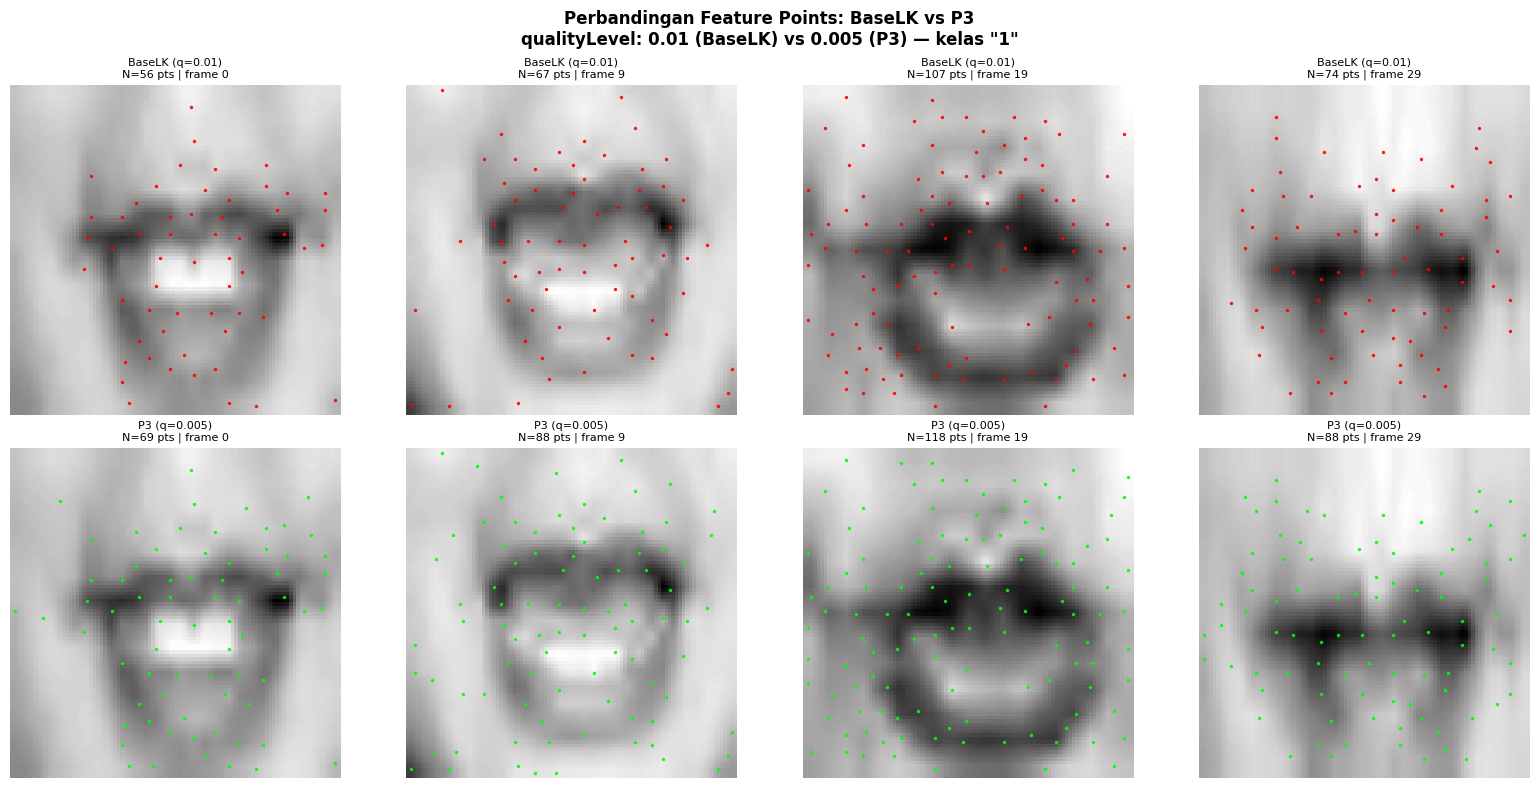

Saved: p3_vs_baselk_corners.png


In [6]:
# ── Cell 6: Visualisasi P3 vs BaseLK — jumlah corner terdeteksi ─────────────
# Bandingkan FEAT_PARAMS P3 dengan BaseLK di frame yang sama
BASELK_FEAT = dict(maxCorners=200, qualityLevel=0.01, minDistance=5, blockSize=5)

sample_cls  = cfg['data']['classes_angka'][0]
sample_file = sorted((RAW_LIPS / 'train' / sample_cls).glob('*.npy'))[0]
frames_test = load_gray(sample_file)
n_show = min(4, len(frames_test))
show_idx = np.linspace(0, len(frames_test)-1, n_show, dtype=int)

fig, axes = plt.subplots(2, n_show, figsize=(4*n_show, 8))
fig.suptitle(f'Perbandingan Feature Points: BaseLK vs P3\n'
             f'qualityLevel: 0.01 (BaseLK) vs 0.005 (P3) — kelas "{sample_cls}"',
             fontsize=12, fontweight='bold')

for col, fi in enumerate(show_idx):
    for row, (params, label, color) in enumerate([
        (BASELK_FEAT, 'BaseLK (q=0.01)', 'red'),
        (FEAT_PARAMS, 'P3 (q=0.005)',    'lime'),
    ]):
        ax = axes[row, col]
        ax.imshow(frames_test[fi], cmap='gray')
        p0 = cv2.goodFeaturesToTrack(frames_test[fi], mask=None, **params)
        n_pts = 0
        if p0 is not None:
            pts = p0.reshape(-1, 2)
            ax.scatter(pts[:, 0], pts[:, 1], s=6, c=color, alpha=0.9, linewidths=0)
            n_pts = len(pts)
        ax.set_title(f'{label}\nN={n_pts} pts | frame {fi}', fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p3_vs_baselk_corners.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_vs_baselk_corners.png')

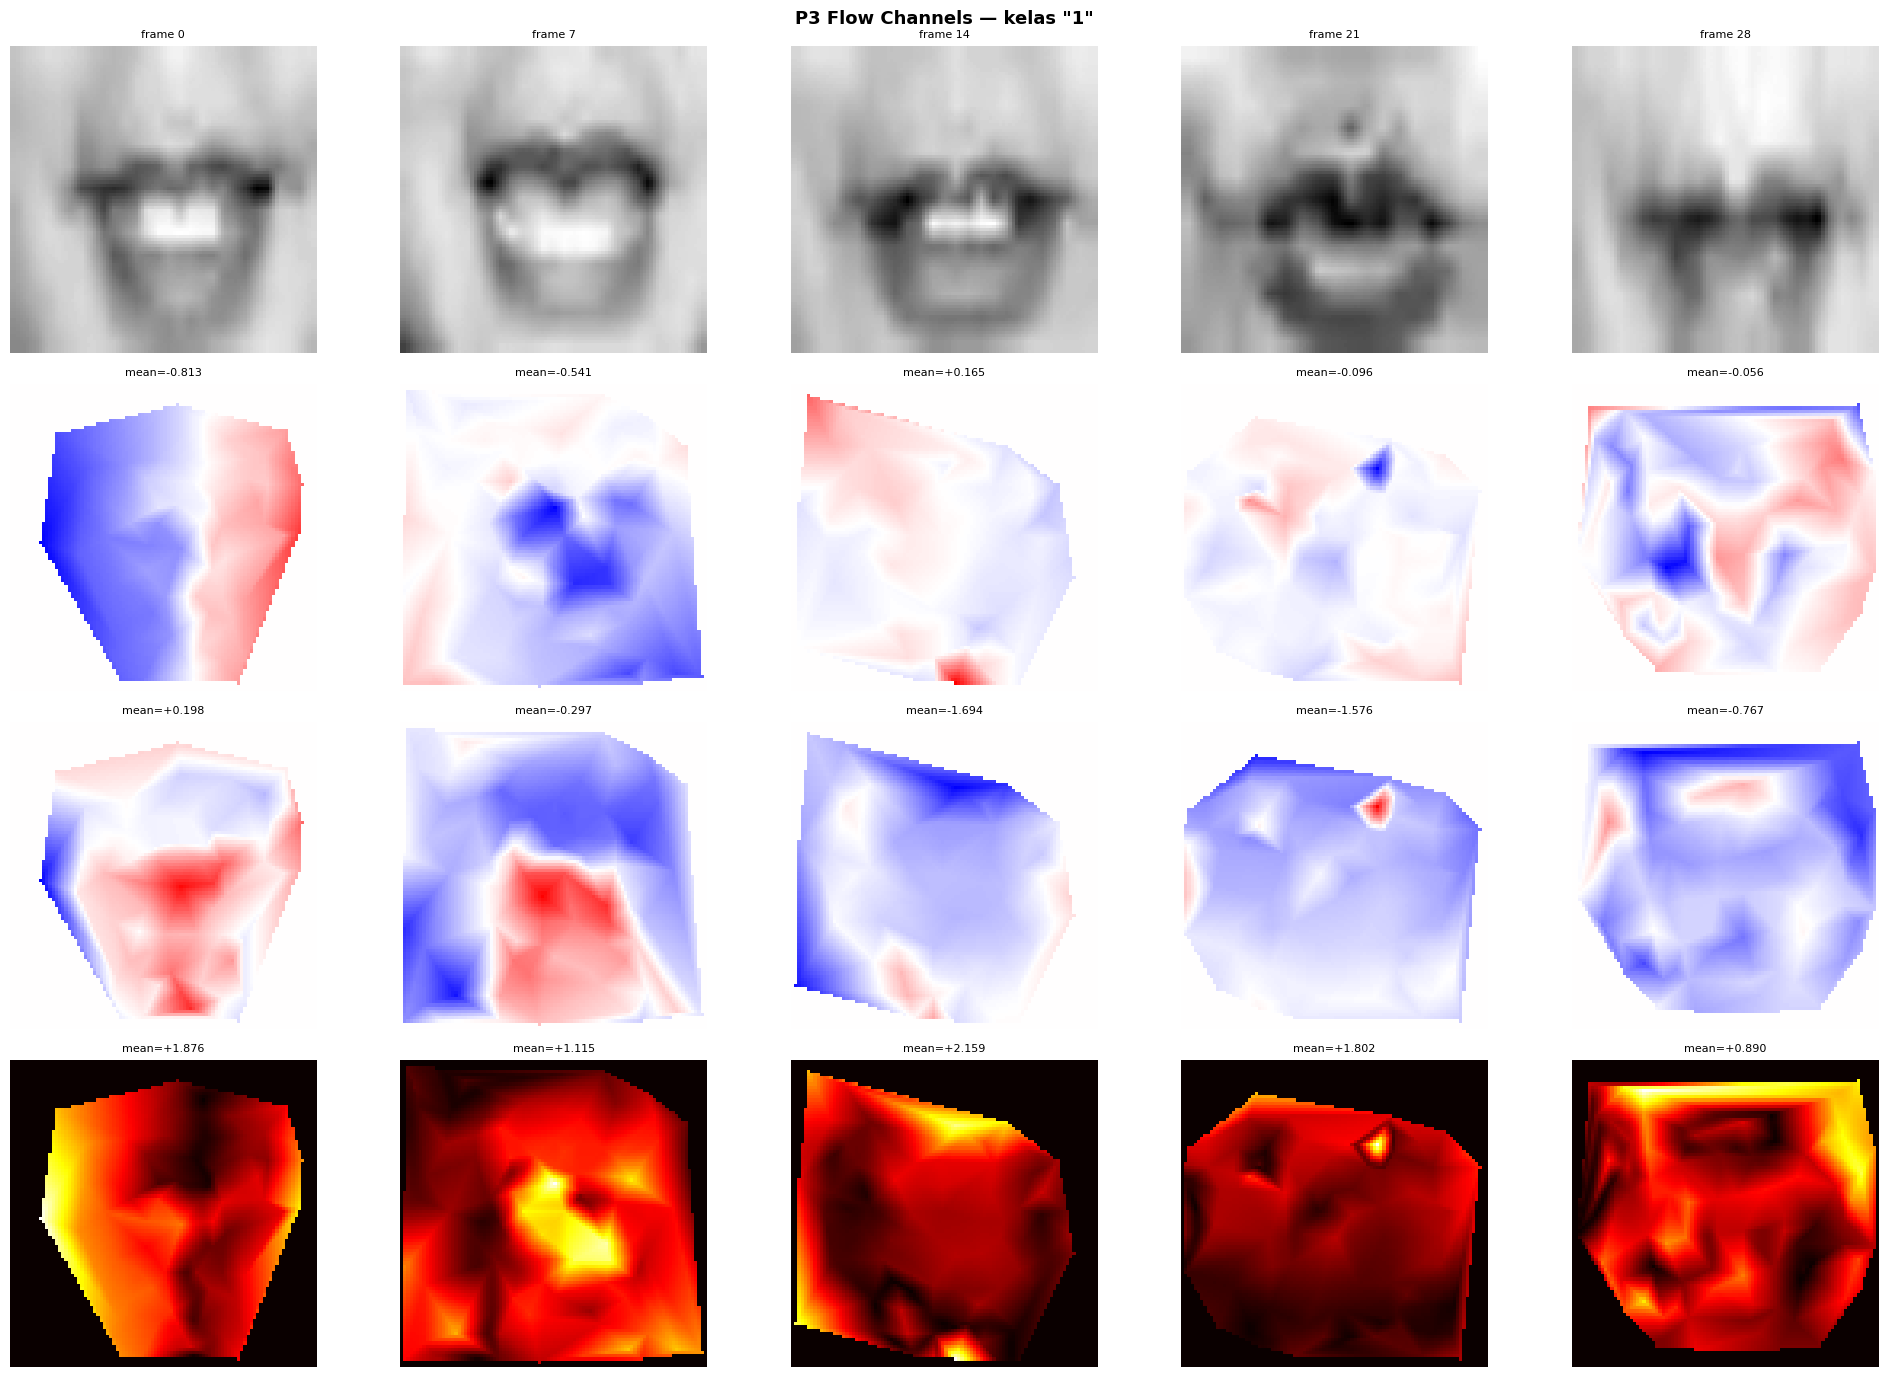

Saved: p3_flow_channels.png


In [7]:
# ── Cell 7: Visualisasi 3 channel flow P3 ───────────────────────────────────
flows_vis = compute_lk_flow(frames_test)
n_show    = min(5, len(flows_vis))
show_idx  = np.linspace(0, len(flows_vis)-1, n_show, dtype=int)

fig, axes = plt.subplots(4, n_show, figsize=(4*n_show, 14))
fig.suptitle(f'P3 Flow Channels — kelas "{sample_cls}"', fontsize=13, fontweight='bold')

row_labels = ['Frame Asli', 'u (horizontal)', 'v (vertikal)', 'magnitude']
row_cmaps  = ['gray', 'bwr', 'bwr', 'hot']
for col, fi in enumerate(show_idx):
    for row in range(4):
        ax = axes[row, col]
        if row == 0:
            ax.imshow(frames_test[fi], cmap='gray')
            ax.set_title(f'frame {fi}', fontsize=8)
        else:
            ch   = row - 1
            data = flows_vis[fi, :, :, ch]
            vabs = max(abs(data.min()), abs(data.max())) if ch < 2 else None
            ax.imshow(data, cmap=row_cmaps[row],
                      vmin=-vabs if ch < 2 else None,
                      vmax= vabs if ch < 2 else None)
            ax.set_title(f'mean={data.mean():+.3f}', fontsize=8)
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=9, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p3_flow_channels.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_flow_channels.png')

---
## Statistik Global & Normalisasi

In [8]:
# ── Cell 8: PASS 1 — Statistik training set ─────────────────────────────────
print('PASS 1: hitung statistik training set (P3)...')
train_files = [f for cls in CLASSES for f in sorted((RAW_LIPS/'train'/cls).glob('*.npy'))]
print(f'Total train files: {len(train_files)}')

n_px = np.zeros(3, dtype=np.float64)
mean = np.zeros(3, dtype=np.float64)
M2   = np.zeros(3, dtype=np.float64)
failed = []

for f in tqdm(train_files, desc='Computing stats P3'):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is None: continue
        for ch in range(3):
            for x in flows[..., ch].ravel():
                n_px[ch] += 1
                delta = x - mean[ch]
                mean[ch] += delta / n_px[ch]
                M2[ch]   += delta * (x - mean[ch])
    except Exception as e:
        failed.append(f.name)

std = np.maximum(np.sqrt(M2 / (n_px - 1)), 1e-6)

print('\nHitung clip percentile...')
buf = []
for f in tqdm(train_files[:150], desc='Percentile', leave=False):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is not None: buf.append(flows[::2, ::4, ::4, :])
    except: pass

if buf:
    cat      = np.concatenate(buf, axis=0)
    clip_min = np.percentile(cat, 2,  axis=(0, 1, 2))
    clip_max = np.percentile(cat, 98, axis=(0, 1, 2))
else:
    clip_min, clip_max = mean - 3*std, mean + 3*std

stats = {
    'mean': mean.tolist(), 'std': std.tolist(),
    'clip_min': clip_min.tolist(), 'clip_max': clip_max.tolist(),
    'n_files': len(train_files) - len(failed),
    'channels': ['u', 'v', 'magnitude'],
    'method': 'lucas-kanade',
    'config': 'P3',
    'feat_params': {str(k): v for k, v in FEAT_PARAMS.items()}
}
with open(STATS_FILE, 'w') as f:
    json.dump(stats, f, indent=2)

print(f'\nStatistik P3 ({len(train_files)-len(failed)} file):')
for i, ch in enumerate(['u', 'v', 'magnitude']):
    print(f'  {ch:9s}: mean={mean[i]:+.4f}, std={std[i]:.4f}, clip=[{clip_min[i]:+.3f}, {clip_max[i]:+.3f}]')
print(f'Saved: {STATS_FILE}')

PASS 1: hitung statistik training set (P3)...
Total train files: 2520


Computing stats P3:   0%|          | 0/2520 [00:00<?, ?it/s]


Hitung clip percentile...


Percentile:   0%|          | 0/150 [00:00<?, ?it/s]


Statistik P3 (2519 file):
  u        : mean=-0.0055, std=3.2257, clip=[-6.835, +6.581]
  v        : mean=-0.1001, std=4.1083, clip=[-10.115, +8.995]
  magnitude: mean=+2.8040, std=4.4080, clip=[+0.000, +15.822]
Saved: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lk_p3/norm_stats.json


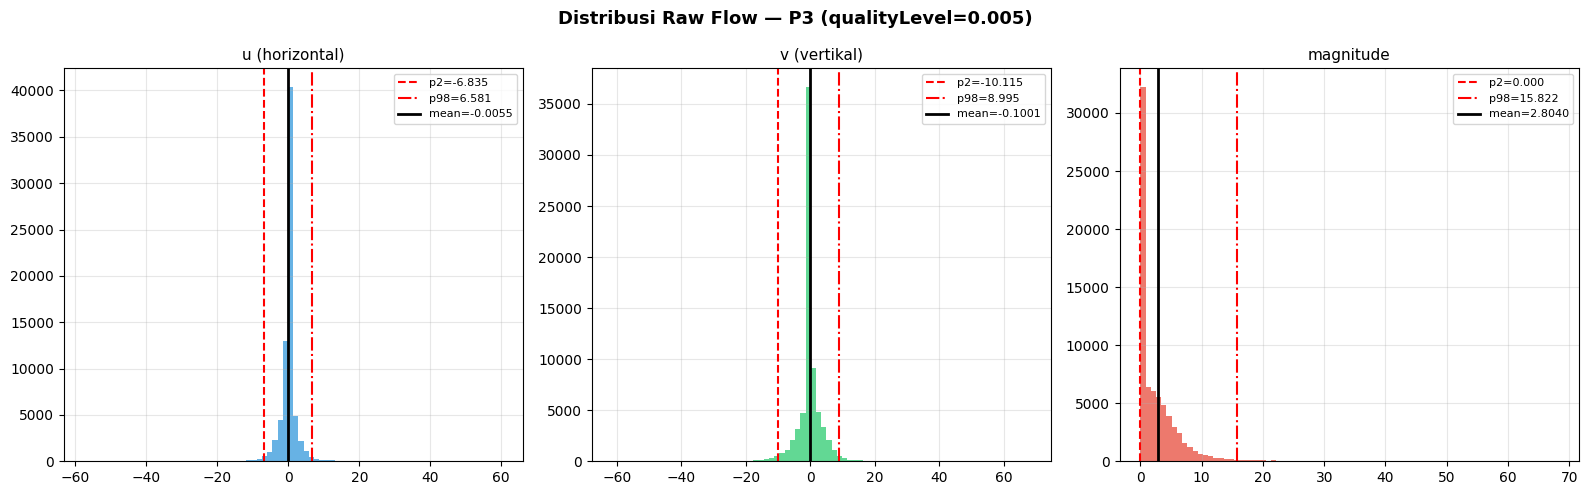

Saved: p3_distribution_raw.png


In [9]:
# ── Cell 9: Distribusi raw flow P3 ──────────────────────────────────────────
dist_buf = []
for f in random.sample(train_files, min(50, len(train_files))):
    try:
        flows = compute_lk_flow(load_gray(f))
        if flows is not None: dist_buf.append(flows[::3, ::8, ::8, :].reshape(-1, 3))
    except: pass

if dist_buf:
    dist_data = np.concatenate(dist_buf, axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Distribusi Raw Flow — P3 (qualityLevel=0.005)', fontsize=13, fontweight='bold')
    for i, (ch, col) in enumerate(zip(['u (horizontal)', 'v (vertikal)', 'magnitude'],
                                       ['#3498db', '#2ecc71', '#e74c3c'])):
        d = dist_data[:, i]
        axes[i].hist(d, bins=80, color=col, alpha=0.75, edgecolor='none')
        axes[i].axvline(float(clip_min[i]), color='red', ls='--', lw=1.5, label=f'p2={clip_min[i]:.3f}')
        axes[i].axvline(float(clip_max[i]), color='red', ls='-.',  lw=1.5, label=f'p98={clip_max[i]:.3f}')
        axes[i].axvline(float(mean[i]), color='black', ls='-', lw=2, label=f'mean={mean[i]:.4f}')
        axes[i].set_title(ch, fontsize=11); axes[i].legend(fontsize=8); axes[i].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'p3_distribution_raw.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: p3_distribution_raw.png')

In [10]:
# ── Cell 10: PASS 2 — Batch processing ──────────────────────────────────────
import time as _time
with open(STATS_FILE) as f: stats = json.load(f)
G_MEAN = np.array(stats['mean'],     dtype=np.float32)
G_STD  = np.array(stats['std'],      dtype=np.float32)
G_CMIN = np.array(stats['clip_min'], dtype=np.float32)
G_CMAX = np.array(stats['clip_max'], dtype=np.float32)

def normalize(flows):
    out = flows.copy()
    for ch in range(3):
        out[..., ch] = np.clip(out[..., ch], G_CMIN[ch], G_CMAX[ch])
        out[..., ch] = (out[..., ch] - G_MEAN[ch]) / G_STD[ch]
    return out.astype(np.float32)

for split in SPLITS:
    for cls in CLASSES:
        (FLOWS_DIR / split / cls).mkdir(parents=True, exist_ok=True)

ok, fail, fail_log = 0, 0, []
t_start = _time.time()
print('PASS 2: proses semua data (P3)...\n')

for split in SPLITS:
    print(f'--- {split.upper()} ---')
    for cls in CLASSES:
        out_dir = FLOWS_DIR / split / cls
        for f in tqdm(sorted((RAW_LIPS/split/cls).glob('*.npy')), desc=f'{split}/{cls}', leave=False):
            out_path = out_dir / f.name
            if out_path.exists(): ok += 1; continue
            try:
                flows = compute_lk_flow(load_gray(f))
                if flows is None or len(flows) < 5: fail += 1; fail_log.append({'split':split,'class':cls,'file':f.name,'reason':'flow failed'}); continue
                np.save(out_path, normalize(flows))
                ok += 1
            except Exception as e:
                fail += 1; fail_log.append({'split':split,'class':cls,'file':f.name,'reason':str(e)})

print(f'\nSelesai dalam {(_time.time()-t_start)/60:.1f} menit | OK: {ok} | Gagal: {fail}')

PASS 2: proses semua data (P3)...

--- TRAIN ---


train/1:   0%|          | 0/140 [00:00<?, ?it/s]

train/2:   0%|          | 0/140 [00:00<?, ?it/s]

train/3:   0%|          | 0/140 [00:00<?, ?it/s]

train/8:   0%|          | 0/140 [00:00<?, ?it/s]

...

test/saya:   0%|          | 0/20 [00:00<?, ?it/s]

test/keliling:   0%|          | 0/20 [00:00<?, ?it/s]

test/kelompok:   0%|          | 0/20 [00:00<?, ?it/s]

test/sekarang:   0%|          | 0/20 [00:00<?, ?it/s]


Selesai dalam 0.0 menit | OK: 3599 | Gagal: 1


---
## Verifikasi Output

In [11]:
# ── Cell 11: Verifikasi jumlah & shape ──────────────────────────────────────
rows = []
for split in SPLITS:
    for cls in CLASSES:
        n_src = len(list((RAW_LIPS  / split / cls).glob('*.npy')))
        n_out = len(list((FLOWS_DIR / split / cls).glob('*.npy')))
        rows.append({'split': split, 'class': cls, 'raw': n_src, 'p3': n_out, 'selisih': n_src - n_out})

df_ver = pd.DataFrame(rows)
pivot  = df_ver.pivot_table(index='class', columns='split', values='selisih', aggfunc='sum')
print('Selisih (raw - p3), idealnya 0:')
print(pivot.to_string())
print(f'\nTotal kurang: {df_ver["selisih"].sum()}')

expected = (29, 96, 96, 3)
print(f'\nCek shape (expected {expected}):')
for cls in CLASSES:
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    if files:
        arr = np.load(random.choice(files))
        status = 'OK' if arr.shape == expected else f'ERR {arr.shape}'
        print(f'  {cls:>4}: {arr.shape}  dtype={arr.dtype}  → {status}')

Selisih (raw - p3), idealnya 0:
split     test  train  val
class                     
1            0      0    0
10           0      0    0
2            0      0    0
3            0      0    0
8            0      0    0
9            0      0    0
a            0      0    0
b            0      1    0
buku         0      0    0
c            0      0    0
d            0      0    0
dia          0      0    0
e            0      0    0
f            0      0    0
keliling     0      0    0
kelompok     0      0    0
saya         0      0    0
sekarang     0      0    0

Total kurang: 1

Cek shape (expected (29, 96, 96, 3)):
     1: (29, 96, 96, 3)  dtype=float32  → OK
     2: (29, 96, 96, 3)  dtype=float32  → OK
     3: (29, 96, 96, 3)  dtype=float32  → OK
     8: (29, 96, 96, 3)  dtype=float32  → OK
     9: (29, 96, 96, 3)  dtype=float32  → OK
    10: (29, 96, 96, 3)  dtype=float32  → OK
     a: (29, 96, 96, 3)  dtype=float32  → OK
     b: (29, 96, 96, 3)  dtype=float32  → OK
     c: (29,

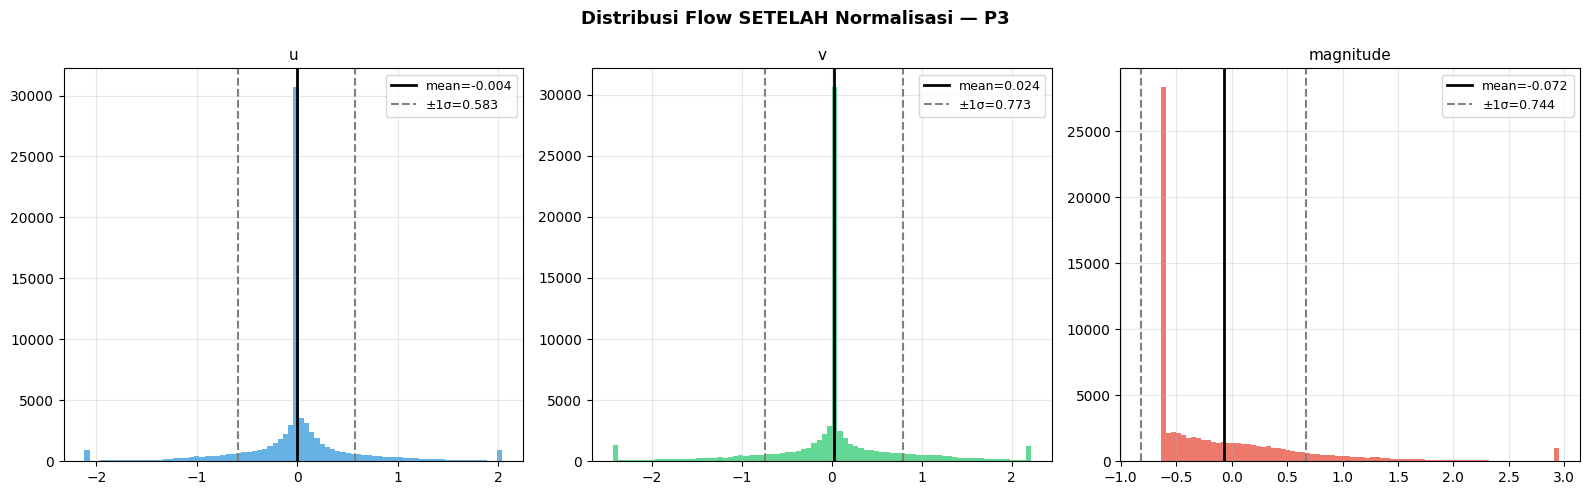

Saved: p3_distribution_normalized.png


In [12]:
# ── Cell 12: Visualisasi distribusi sesudah normalisasi ─────────────────────
norm_buf = []
for cls in CLASSES:
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    for f in random.sample(files, min(3, len(files))):
        norm_buf.append(np.load(f)[::3, ::8, ::8, :].reshape(-1, 3))

norm_data = np.concatenate(norm_buf, axis=0)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribusi Flow SETELAH Normalisasi — P3', fontsize=13, fontweight='bold')
for i, (ch, col) in enumerate(zip(['u', 'v', 'magnitude'], ['#3498db', '#2ecc71', '#e74c3c'])):
    d = norm_data[:, i]
    axes[i].hist(d, bins=80, color=col, alpha=0.75, edgecolor='none')
    axes[i].axvline(d.mean(), color='black', ls='-', lw=2, label=f'mean={d.mean():.3f}')
    axes[i].axvline(d.mean()+d.std(), color='gray', ls='--', lw=1.5, label=f'±1σ={d.std():.3f}')
    axes[i].axvline(d.mean()-d.std(), color='gray', ls='--', lw=1.5)
    axes[i].set_title(ch, fontsize=11); axes[i].legend(fontsize=9); axes[i].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p3_distribution_normalized.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_distribution_normalized.png')

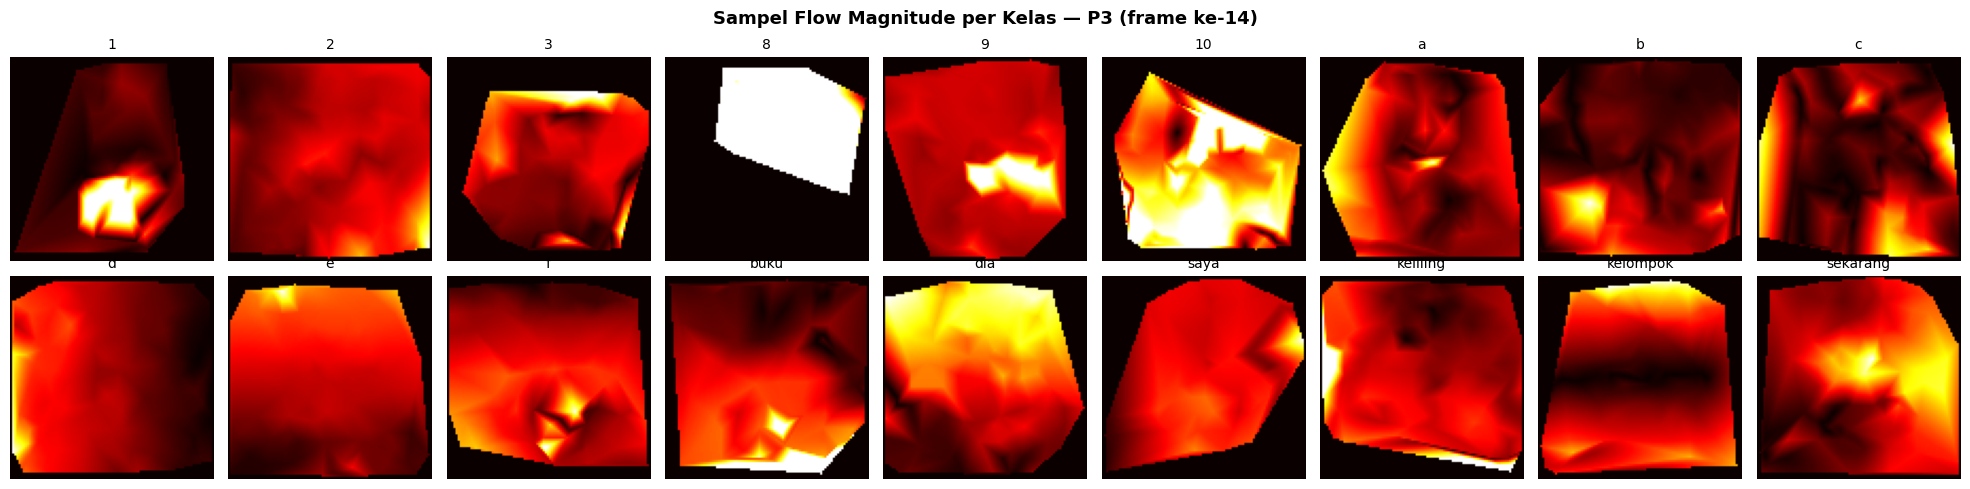

Saved: p3_samples_per_class.png


In [13]:
# ── Cell 13: Sampel magnitude per kelas ─────────────────────────────────────
n_cls = len(CLASSES); n_cols = 9; n_rows = (n_cls + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2.2, n_rows*2.5))
fig.suptitle('Sampel Flow Magnitude per Kelas — P3 (frame ke-14)', fontsize=13, fontweight='bold')
for idx, cls in enumerate(CLASSES):
    ax    = axes.flatten()[idx]
    files = list((FLOWS_DIR / 'train' / cls).glob('*.npy'))
    if files: ax.imshow(np.load(random.choice(files))[14, :, :, 2], cmap='hot')
    ax.set_title(cls, fontsize=10); ax.axis('off')
for idx in range(n_cls, n_rows*n_cols): axes.flatten()[idx].axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'p3_samples_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p3_samples_per_class.png')

In [14]:
# ── Cell 14: Summary ────────────────────────────────────────────────────────
total_npy = sum(len(list((FLOWS_DIR/split/cls).glob('*.npy'))) for split in SPLITS for cls in CLASSES)
if fail_log:
    pd.DataFrame(fail_log).to_csv(RESULTS_DIR / 'fail_log_p3.csv', index=False)

print('=' * 60)
print('  LK P3 PREPROCESSING SELESAI')
print('=' * 60)
print(f'  Config          : P3 (qualityLevel=0.005)')
print(f'  Total file .npy : {total_npy}')
print(f'  Output shape    : (29, 96, 96, 3)')
print(f'  Output dir      : {FLOWS_DIR}')
print(f'  Gagal           : {fail} file')
print('=' * 60)
print('→ Lanjut ke Notebook 06b: Training LK P3')

  LK P3 PREPROCESSING SELESAI
  Config          : P3 (qualityLevel=0.005)
  Total file .npy : 3599
  Output shape    : (29, 96, 96, 3)
  Output dir      : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/preprocessed/dependent/flows_lk_p3
  Gagal           : 1 file
→ Lanjut ke Notebook 06b: Training LK P3
